In [38]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report,roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split

In [39]:
# Set random seed for reproducibility
np.random.seed(42)

# generate  imbalanced daatset
n_sample_1=25 ## Number of samples in class 1
n_sample_2=375 # Number of samples in class 2
centers=[(0,0),(2,2)] # Centers of each cluster
cluster_std=[1.5,1.5] # Standard deviation of each cluster

In [40]:
x,y=make_blobs(n_samples=[n_sample_1,n_sample_2],centers=centers,cluster_std=cluster_std,random_state=0)

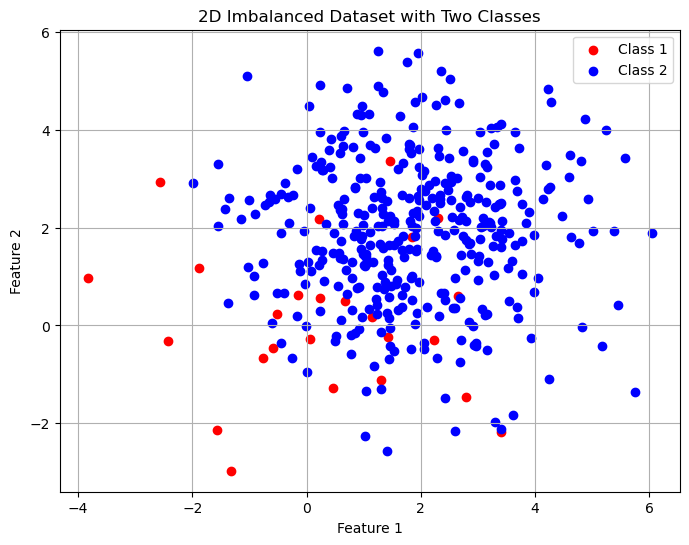

In [41]:

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color='red', label='Class 1')
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


In [42]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

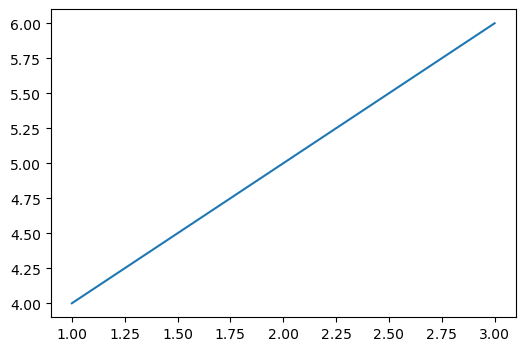

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot([1,2,3],[4,5,6])
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.14      0.22         7
           1       0.95      0.99      0.97       113

    accuracy                           0.94       120
   macro avg       0.72      0.57      0.60       120
weighted avg       0.92      0.94      0.93       120

ROC AUC Score: 0.7193426042983565


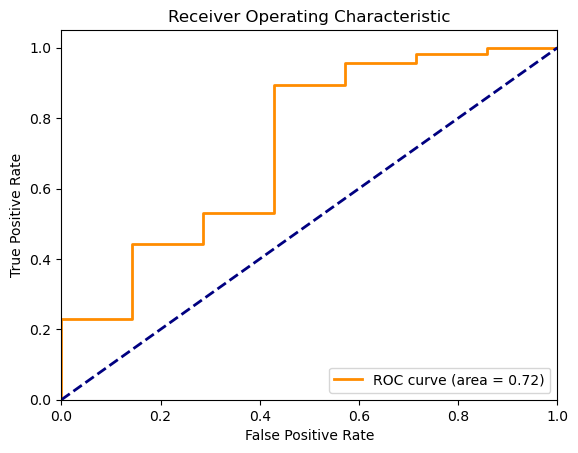

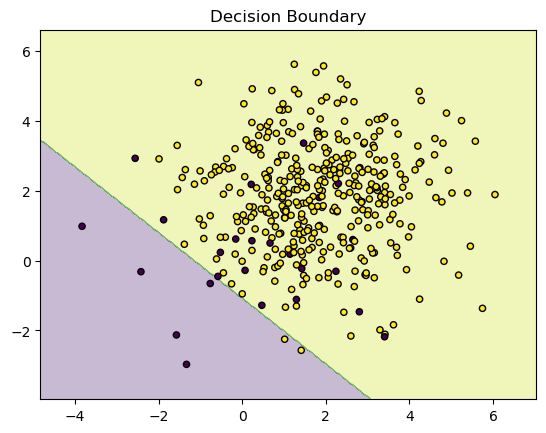

In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

# Initialize and train RandomForest classifier
classifier = LogisticRegression()
classifier.fit(x_train, y_train)

# Predict test set
y_pred = classifier.predict(x_test)
y_proba = classifier.predict_proba(x_test)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()

# Plot decision boundary
plot_decision_boundaries(x, y, classifier)
plt.show()


# Random Undersampling 

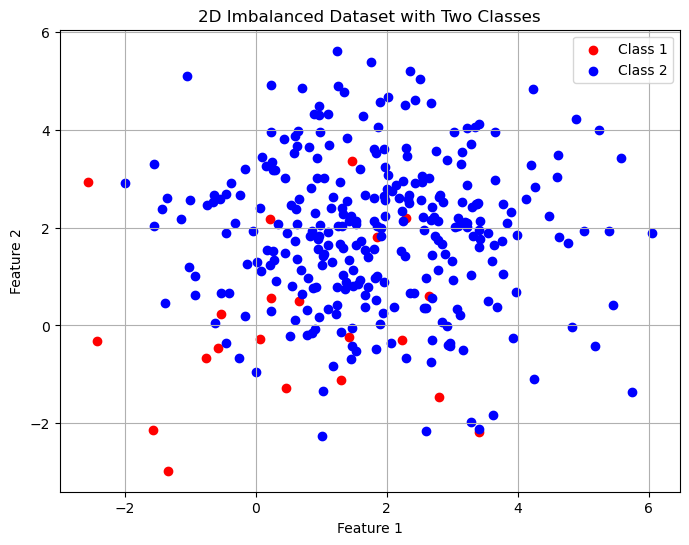

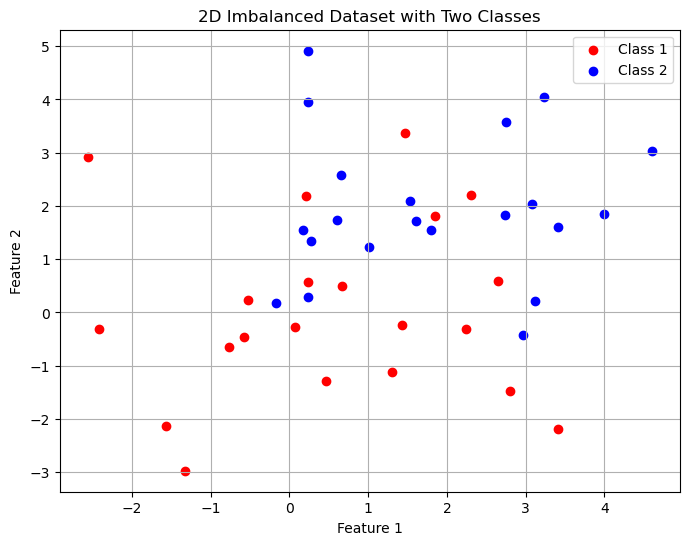

In [45]:
from imblearn.under_sampling import RandomUnderSampler
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Apllying Random Undersamplinng
rus=RandomUnderSampler(random_state=42)
x_resmapled,y_resampled=rus.fit_resample(x_train,y_train)



# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], color='red', label='Class 1')
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x_resmapled[y_resampled == 0][:, 0], x_resmapled[y_resampled == 0][:, 1], color='red', label='Class 1')
plt.scatter(x_resmapled[y_resampled == 1][:, 0], x_resmapled[y_resampled == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
x_train.shape

(320, 2)

In [47]:
x_resmapled.shape

(42, 2)

In [48]:
import pandas as pd
pd.Series(y_train).value_counts()

1    299
0     21
Name: count, dtype: int64

In [49]:
pd.Series(y_resampled).value_counts()

0    21
1    21
Name: count, dtype: int64

Classification Report (With Over Sampling):
              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80

ROC AUC Score (With Over Sampling): 0.9375


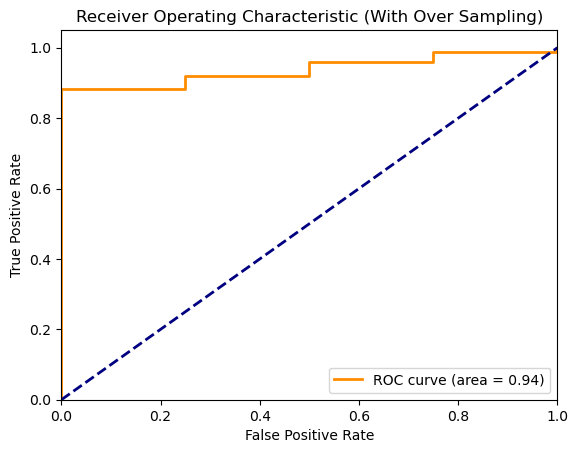

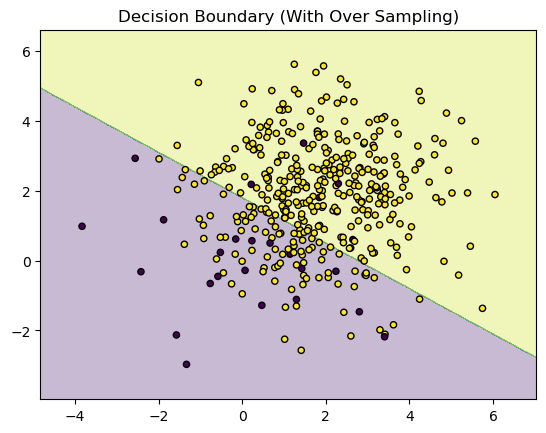

In [50]:
from sklearn.linear_model import LogisticRegression
classifier_rus=LogisticRegression()
classifier_rus.fit(x_resmapled,y_resampled)

# predict test set
y_pred_rus=classifier_rus.predict(x_test)
y_proba_rus=classifier_rus.predict_proba(x_test)[:,1]

# Print classification report for resampled data
print("Classification Report (With Over Sampling):")
print(classification_report(y_test, y_pred_rus))

# Print ROC AUC Score for resampled data
print("ROC AUC Score (With Over Sampling):", roc_auc_score(y_test, y_proba_rus))

# Plotting ROC AUC Curve for resampled data
fpr_rus, tpr_rus, _ = roc_curve(y_test, y_proba_rus)
plt.figure()
plt.plot(fpr_rus, tpr_rus, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_rus))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Over Sampling)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for resampled data
def plot_decision_boundaries_ros(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With Over Sampling)")
    plt.show()

# Plot decision boundary for resampled data
plot_decision_boundaries_ros(x, y, classifier_rus)

# Rndom Oversampling

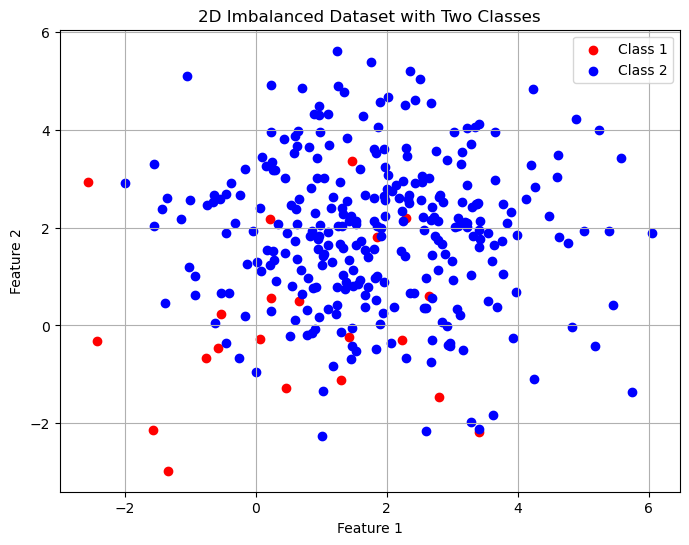

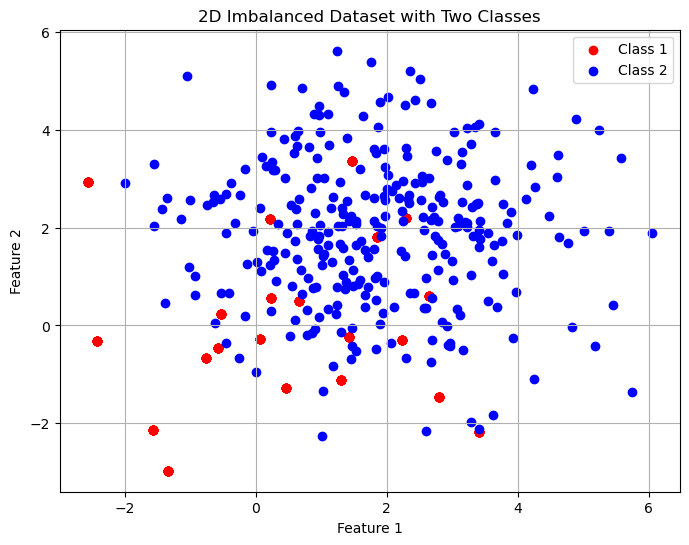

In [51]:
from imblearn.over_sampling import RandomOverSampler
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

ros=RandomOverSampler(random_state=42)
x_resmapled,y_resampled=ros.fit_resample(x_train,y_train)



# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], color='red', label='Class 1')
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x_resmapled[y_resampled == 0][:, 0], x_resmapled[y_resampled == 0][:, 1], color='red', label='Class 1')
plt.scatter(x_resmapled[y_resampled == 1][:, 0], x_resmapled[y_resampled == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [52]:
x_train.shape

(320, 2)

In [53]:
x_resmapled.shape

(598, 2)

In [54]:
pd.Series(y_train).value_counts()

1    299
0     21
Name: count, dtype: int64

In [55]:
pd.Series(y_resampled).value_counts()

1    299
0    299
Name: count, dtype: int64

Classification Report (With Over Sampling):
              precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80

ROC AUC Score (With Over Sampling): 0.950657894736842


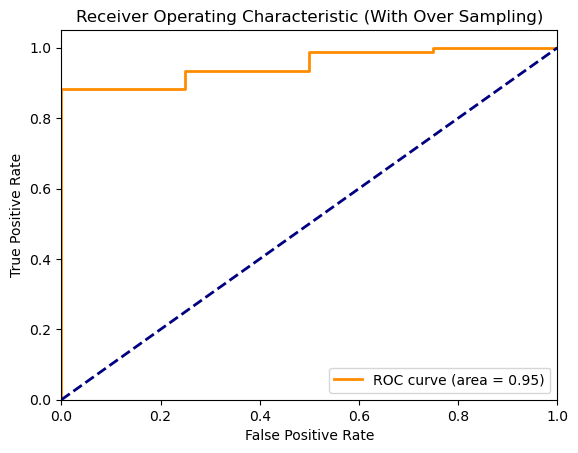

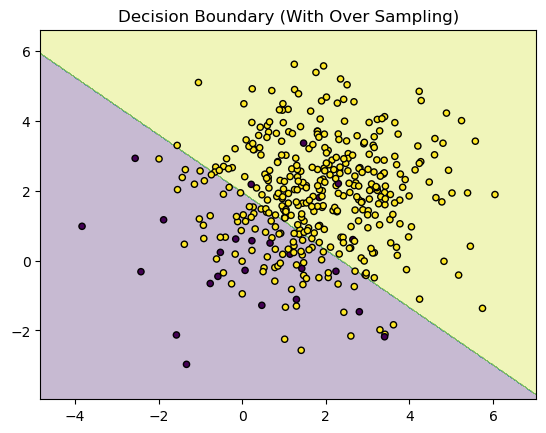

In [56]:
classifier_rus=LogisticRegression()
classifier_rus.fit(x_resmapled,y_resampled)

y_pred_rus=classifier_rus.predict(x_test)
y_proba_rus=classifier_rus.predict_proba(x_test)[:,1]



# Print classification report for resampled data
print("Classification Report (With Over Sampling):")
print(classification_report(y_test, y_pred_rus))

# Print ROC AUC Score for resampled data
print("ROC AUC Score (With Over Sampling):", roc_auc_score(y_test, y_proba_rus))

# Plotting ROC AUC Curve for resampled data
fpr_ros, tpr_ros, _ = roc_curve(y_test, y_proba_rus)
plt.figure()
plt.plot(fpr_ros, tpr_ros, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_rus))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Over Sampling)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for resampled data
def plot_decision_boundaries_ros(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With Over Sampling)")
    plt.show()

# Plot decision boundary for resampled data
plot_decision_boundaries_ros(x, y, classifier_rus)


# SMOTE 

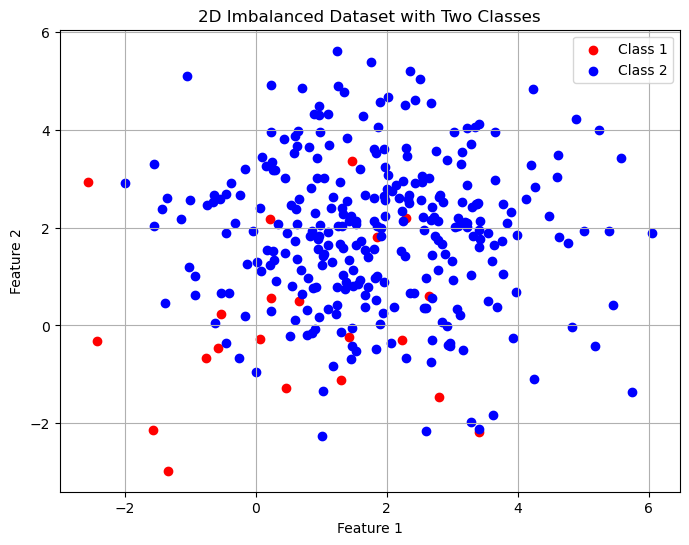

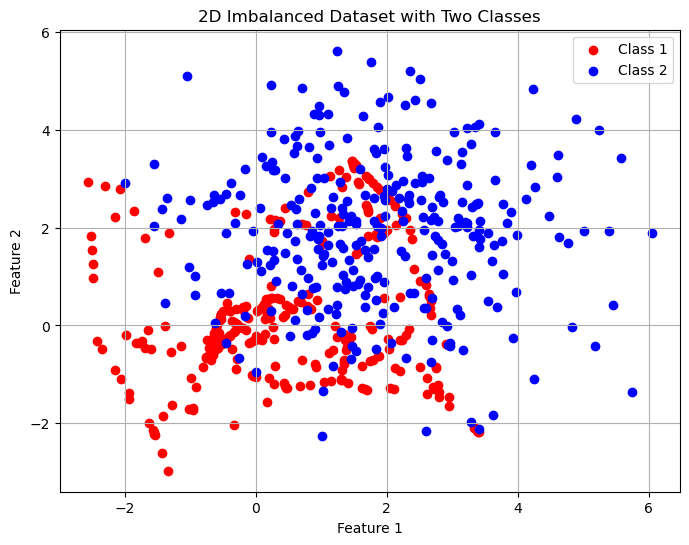

In [57]:
from imblearn.over_sampling import SMOTE

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

smote=SMOTE(random_state=42)
x_resmapled_smote,y_resampled_smote=smote.fit_resample(x_train,y_train)




# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], color='red', label='Class 1')
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x_resmapled_smote[y_resampled_smote == 0][:, 0], x_resmapled_smote[y_resampled_smote == 0][:, 1], color='red', label='Class 1')
plt.scatter(x_resmapled_smote[y_resampled_smote == 1][:, 0], x_resmapled_smote[y_resampled_smote == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with Two Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
x_train.shape

(320, 2)

In [59]:
x_resmapled_smote.shape

(598, 2)

In [60]:
pd.Series(y_train).value_counts()

1    299
0     21
Name: count, dtype: int64

In [61]:
pd.Series(y_resampled_smote).value_counts()

1    299
0    299
Name: count, dtype: int64

Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       0.17      1.00      0.30         4
           1       1.00      0.75      0.86        76

    accuracy                           0.76        80
   macro avg       0.59      0.88      0.58        80
weighted avg       0.96      0.76      0.83        80

ROC AUC Score (With SMOTE): 0.950657894736842


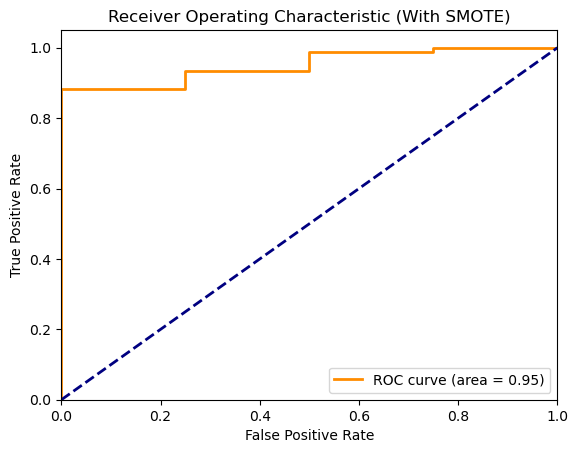

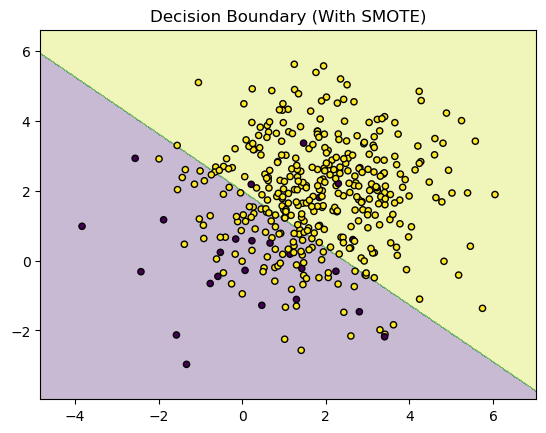

In [62]:
classifier_smote=LogisticRegression()
classifier_smote.fit(x_resmapled_smote,y_resampled_smote)


y_pred_smote=classifier_smote.predict(x_test)
y_proba_smote=classifier_smote.predict_proba(x_test)[:,1]



# Print classification report for SMOTE data
print("Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred_smote))

# Print ROC AUC Score for SMOTE data
print("ROC AUC Score (With SMOTE):", roc_auc_score(y_test, y_proba_smote))

# Plotting ROC AUC Curve for SMOTE data
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)
plt.figure()
plt.plot(fpr_smote, tpr_smote, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_smote))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With SMOTE)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With SMOTE)")
    plt.show()

# Plot decision boundary for SMOTE data
plot_decision_boundaries_smote(x, y, classifier_smote)